# Libraries

In [ ]:
from functions import *
from UQpy.distributions import Normal, JointIndependent
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import seaborn as sns
import numpy as np

# Dataset

### $R$ and $S$ realization

In [ ]:
n_samples = 1
n_latent_samples = 2000
time = [0., 10., 20., 30., 40., 50., 60., 70., 80., 90., 100.]
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)
joint = JointIndependent(marginals=[r, s])
x = joint.rvs(n_samples)
x

array([[4.45720422, 1.81670032]])

In [ ]:
n_samples = 1
n_latent_samples = 2000
time = [0., 10., 20., 30., 40., 50., 60., 70., 80., 90., 100.]
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)
joint = JointIndependent(marginals=[r, s])
x = joint.rvs(n_samples)
x

array([[4.45720422, 1.81670032]])

### $g$ over the time

In [52]:
lambdas = []
gs = []
for k in time:
    y, df = state_limit_function_time(x, n_latent_samples, t=k)
    lambdas.append(y)
    gs.append(df[0])

In [53]:
lambdas = np.vstack(lambdas)
lambdas

array([[ 2.64735059,  6.80242779,  0.10696099,  0.1726277 ],
       [ 2.34416417,  6.89709919,  0.11250587,  0.18089985],
       [ 2.02916353,  7.07230078,  0.10852705,  0.17978505],
       [ 1.71204233,  7.36495155,  0.10734813,  0.15524699],
       [ 1.39970865,  7.62269493,  0.1001758 ,  0.14684133],
       [ 1.088708  ,  7.50205666,  0.10780875,  0.19379611],
       [ 0.78285222,  7.84170613,  0.06845412,  0.19066617],
       [ 0.46620991,  8.12508533,  0.07347467,  0.17300906],
       [ 0.15754516,  8.218181  ,  0.07828913,  0.1733625 ],
       [-0.15831429,  8.3777307 ,  0.08076182,  0.16100805],
       [-0.46992727,  8.28037657,  0.07569589,  0.17041508]])

# Chart

### $g$ over the time

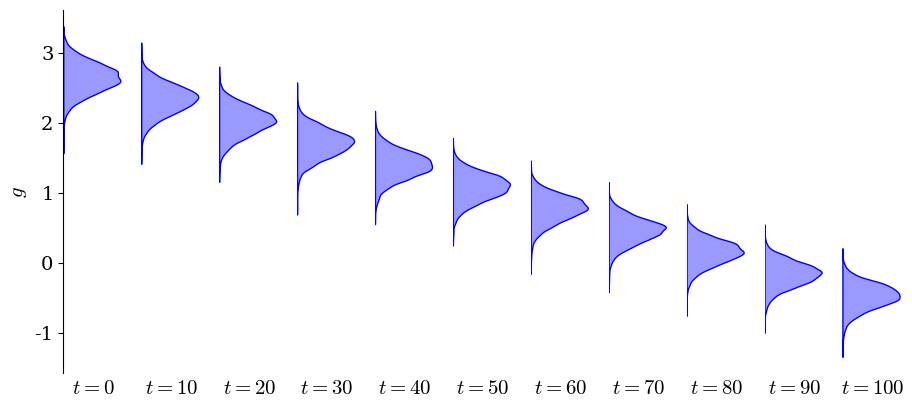

In [ ]:
### Figure name and DPI
dpi = 600
name = 'time-lapse_g_analysis'

### Chart dimensions
b_cm_individual = 2.5      
h_cm = 12                 
inches_to_cm = 1 / 2.54

n_plots = len(time) 
b_input_total = (b_cm_individual * n_plots) * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_y = '$g$'
size_label = 15
color_label = 'black'
size_axis = 14
color_axis = 'black'
color = 'blue'
alpha = 0.4

### Figure
fig, axes = plt.subplots(nrows=1, ncols=n_plots, sharey=True, figsize=(b_input_total, h_input))

### Space between plots
plt.subplots_adjust(wspace=0.3) 

### Loop
for i, ax in enumerate(axes):
    
    ### Plot
    current_data = gs[i]
    sns.kdeplot(y=current_data['g'], fill=True, alpha=alpha, ax=ax, color=color)
    
    # Configurações gerais (Fonte, Cor)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label X
    ax.set_xlabel(f'$t={int(time[i])}$', fontsize=size_label, color=color_label)
    
    # Remove ticks e números do eixo X (como você pediu antes)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Remove bordas padrão (Topo, Direita, Baixo)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # --- AQUI ESTÁ A MÁGICA PARA REMOVER O EIXO Y DOS OUTROS ---
    if i == 0:
        # Primeiro gráfico: Mantém a linha da esquerda e o Label Y
        ax.spines['left'].set_visible(True)
        ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
    else:
        # Do segundo em diante:
        ax.spines['left'].set_visible(False)   # Remove a linha vertical
        ax.tick_params(axis='y', left=False)   # Remove os tracinhos (ticks) da esquerda
        ax.set_ylabel('')                      # Remove o label
        
### Save and Show
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()

### $\lambda$ over the time

In [60]:
x = time.copy()
y1 = lambdas[:,0]
y2 = lambdas[:,1]
y3 = lambdas[:,2]
y4 = lambdas[:,3]
data = [
        {'x': x, 'y': y1},
        {'x': x, 'y': y2},
        {'x': x, 'y': y3},
        {'x': x, 'y': y4}
    ]

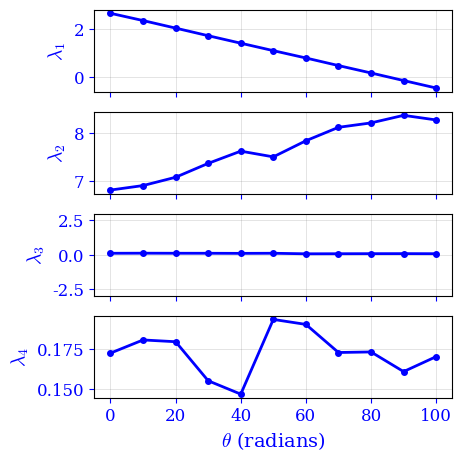

In [ ]:
### Figure name and DPI
dpi = 600
name = 'lambdas_for_r_s_realization'

### Axis and labels
label_x = '$\\theta$ (radians)'  
size_label = 14
color_label = 'blue'
size_axis = 12
color_axis = 'blue'

### Line
size_line = 2
style_line = '-'
color_line = 'blue'

### Marker
marker = 'o'
size_marker = 4
color_marker = 'blue'
color_marker_edge = color_line

### Legend
labels_legend = ['$\lambda _1$', '$\lambda _2$', '$\lambda _3$', '$\lambda _4$']  # Change as you wish
size_legend = 10
location_legend = 'upper right'

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

### Plot
i = 0
for ax, dataset in zip(axes, data):
    
    ax.plot(dataset['x'], dataset['y'],
            markerfacecolor=color_marker, marker=marker, markersize=size_marker,
            linewidth=size_line, linestyle=style_line, color=color_line)
    
    # Configuração dos Eixos (Cores e Tamanhos)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label Y (Específico de cada gráfico, mas com seu estilo)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    i += 1
    
    # Configuração do Grid
    ax.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    
    # # Legenda
    # ax.legend(fontsize=size_legend, loc=location_legend)

# Ajuste específico para a Tangente (índice 2) pois ela vai ao infinito
axes[2].set_ylim(-3, 3)

# Label X apenas no último gráfico
axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

# Ajustar espaçamento
plt.tight_layout()

# --- 6. SALVAR E MOSTRAR ---
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()